In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

In [3]:
img = mpimg.imread("src/map_krikket.png")


/var/folders/4y/pgbdb1gn7p14g40vmzpxxwjw0000gn/T/ipykernel_51345/2791870930.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


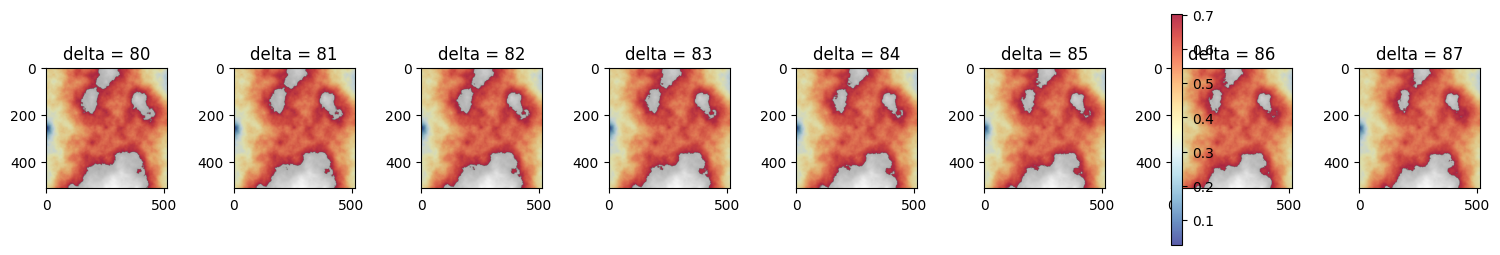

In [4]:
fig, ax = plt.subplots(nrows=1, ncols=8, figsize=(15, 3))

# for idx, i in enumerate(range(54, 59)):
for idx, i in enumerate(range(80, 88)):

    delta = i
    mask = (img*255 < 93 + delta) & (img*255 > 93 - delta)

    # Garder les valeurs originales où le masque est True, NaN ailleurs
    masked_values = np.where(mask, img, np.nan)

    ax[idx].imshow(img, cmap='gray')  # image de fond en gris
    image = ax[idx].imshow(masked_values, cmap='RdYlBu_r', alpha=0.8)  # rouge=haut, bleu=bas
    ax[idx].set_title(f"delta = {delta}")
plt.colorbar(image, ax=ax)

plt.tight_layout()
plt.show()

In [6]:
img * 255


array([[93., 95., 96., ..., 91., 91., 93.],
       [94., 95., 97., ..., 89., 90., 92.],
       [96., 96., 97., ..., 89., 90., 90.],
       ...,
       [95., 97., 97., ..., 95., 94., 95.],
       [94., 96., 97., ..., 95., 94., 95.],
       [93., 95., 96., ..., 95., 94., 93.]],
      shape=(513, 513), dtype=float32)

In [7]:
img_centree = img * 255 - 93
print(img_centree)


[[ 0.  2.  3. ... -2. -2.  0.]
 [ 1.  2.  4. ... -4. -3. -1.]
 [ 3.  3.  4. ... -4. -3. -3.]
 ...
 [ 2.  4.  4. ...  2.  1.  2.]
 [ 1.  3.  4. ...  2.  1.  2.]
 [ 0.  2.  3. ...  2.  1.  0.]]


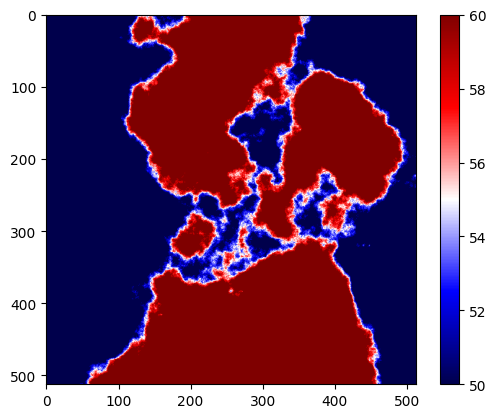

In [14]:
fig, ax = plt.subplots()
image = ax.imshow(img_centree, cmap="seismic", vmin=50, vmax=60)
plt.colorbar(image, ax=ax)
plt.show()


In [10]:
img_centree.max()

np.float32(162.0)

In [26]:
img_centree

array([[ 0.,  2.,  3., ..., -2., -2.,  0.],
       [ 1.,  2.,  4., ..., -4., -3., -1.],
       [ 3.,  3.,  4., ..., -4., -3., -3.],
       ...,
       [ 2.,  4.,  4., ...,  2.,  1.,  2.],
       [ 1.,  3.,  4., ...,  2.,  1.,  2.],
       [ 0.,  2.,  3., ...,  2.,  1.,  0.]],
      shape=(513, 513), dtype=float32)

In [136]:
import random

In [198]:
def min_choice(pixel_row, pixel_col, force: str=None):
    right_limit_reach = True if pixel_col == 512 else False
    bottom_limit_reach = True if pixel_row == 512 else False

    # Cas où on est déjà arrivé au point B (tout en bas à droite) -> On continue de retourner le point B.
    if pixel_row == 512 and pixel_col == 512:
        return pixel_row, pixel_col

    # Cas où on a atteint la dernière ligne -> On ne peut plus descendre donc on va à droite.
    if pixel_row == 512:
        #print(f"On est sur la dernière ligne")
        # On oblige à descendre
        return pixel_row, pixel_col+1

    # Cas où on a atteint la dernière colonne -> On ne peut plus aller à droite donc on descends.
    if pixel_col == 512:
        #print(f"On est sur la dernière colonne")
        # On oblige à aller à droite
        return pixel_row+1, pixel_col

    # On récupère les valeurs du pixel courant, du pixel à sa droite et du pixel en dessous.
    current_pixel = img_centree[pixel_row, pixel_col]
    right_pixel = img_centree[pixel_row, pixel_col+1]
    bottom_pixel = img_centree[pixel_row+1, pixel_col]

    # On se dirige sur le pixel avec le plus petit écart d'altitude p/r au pixel courant.
    if abs(current_pixel - right_pixel) < abs(current_pixel - bottom_pixel):
        return pixel_row, pixel_col+1
    if abs(current_pixel - right_pixel) > abs(current_pixel - bottom_pixel):
        return pixel_row+1, pixel_col

    # Si on a pas encore atteint un bord, en cas d'égalité de dénivelé entre la droite et le bas, on choisi aléatoirement d'aller à droite ou de descendre.
    # ATTENTION: uniquement si la méthode a été appelée sans argument "force".
    if not bottom_limit_reach and not right_limit_reach and not force:
        force = ["bottom", "right"][random.randint(0, 1)]

    # En cas d'égalité de dénivelé avec le pixel droit et le pixel bas, on choisi la direction à prendre via "force".
    if abs(current_pixel - right_pixel) == abs(current_pixel - bottom_pixel):
        if force == "bottom":
            return pixel_row+1, pixel_col
        elif force == "right":
            return pixel_row, pixel_col+1


In [199]:
def compute_denivele(path: list[tuple]) -> int:
    denivele = 0
    alt = [img_centree[row][col] for row, col in path]

    for i in range(len(alt)-1):
        delta = alt[i+1] - alt[i]
        if delta > 0:
            denivele += delta

    return denivele

In [215]:
def compute_itineraire(path: list):
    result = []

    for i in range(len(path)-1):
        current = path[i]
        _next = path[i+1]

        # Si les valeurs de lignes sont égales entre les points i et i+1, ça signifie que c'est la valeur de colonne qui a changé, donc on est aller à droite ('E').
        if current[0] == _next[0]:
            result.append('E')
        # Dans l'autre cas, c'est qu'on est descendu ('S').
        else:
            result.append('S')

    return ''.join(result)

In [209]:
position = (0, 0)
path = []

for i in range(1050):
    path.append(position)
    position = min_choice(position[0], position[1])

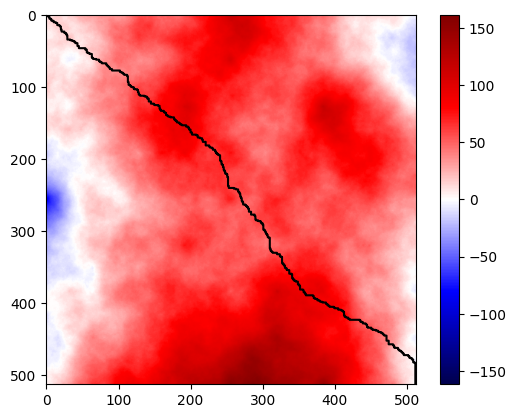

In [210]:
fig, ax = plt.subplots()
image = ax.imshow(img_centree, cmap="seismic", vmin=-162, vmax=162)
plt.colorbar(image, ax=ax)
ax.plot([i[0] for i in path], [i[1] for i in path], color="k")
plt.show()

In [211]:
compute_denivele(path)

np.float32(239.0)

In [214]:
compute_itineraire(path)

'SESESSEEESSESEESSSEESSSESSEEESSSESESEEEESEEESSSSEESSESEESEEEEEESSSSESSSESSESSEESSSEEEESSEEESSSSSSSSSEESSEEEESSESSESSSEEEEESESESSSSESSSSEESESSESESSSSSSEESESESESESEESSSEESSSSSSSSSSSEESSESSESESESSSSEESEEEEEEEESEEEESSESESESSSEESESSSSESEEESEEESESESSSSSSESSSESEESSEEEESSSEEESSSSESESSSSSESSEEEESEESESSSSEESSESEEESSESESSSESSSSSEESEESSESEESSSESESESSESSSSSSEESSSEESEESSEEEESSEEESSSSSSESSEEESSSESSSEESEEESSSSEEEEESSSSSEESESSSESEESSSEESEESESESESSESEEEEEEESESEEEESESEEESEEEESEESEEESSESEEEESEEEEEEEEEEEESEEESSSSSSSESSSESSSEEESESEESEEEESEESEEEESEESEEESSSESESESESEESEEEESSSEEEESSSSSEESEEEEESESSSESSSESEESSEESEEEEEEESSEESEESEESESEEESESSEEEEEEEEEEEEEEESEEESESESESSSSSSEESSSSEEESSESEEEEEEEESEESSEESEEESSEESESSSEEEEESSSESEEEEESEESSEESSESSSEEEESSEESEEEEESSSSESEEESSEESEESSSSSSSSSSESEEESSESSSEESSSESESSSESSSSSEESSEESSESESSSSSSESESSSSSEESSSSESSESESEEEEESEESSESSSEESSESSSSSSSSSSSSSSESEESSSEESSSSESESEEESESSSSSEESSESSSSESSSESESSSESSESESESESSSEEEEEEESSSEEEEESSSSSSESEESEESSSSSEESESESSESESESESEESSSSSSESESEESSSEESSEEEESSESEEEE

## Brut force

In [245]:
# On initialise un dénivelé minimum arbitrairement très élevé
min_denivele = 999999
best_itineraire = []

for i in range(100000):
    position = (0, 0)
    path = []

    for i in range(1050):
        path.append(position)
        position = min_choice(position[0], position[1])

    path_denivele = compute_denivele(path)
    if path_denivele < min_denivele:
        min_denivele = path_denivele

        itineraire = compute_itineraire(path)
        best_itineraire = itineraire

In [246]:
min_denivele

np.float32(214.0)

In [247]:
best_itineraire

'SESESSEEESSEESESSSEEESEEESESSEESEESEEESEEESESEEESSEEEEESSSSEEEESSEEEEESSEESESESSEESSSSEEESESSSEEEEEESSEESSESESSEESEEEEEEESSSSESEESEESSSESSEESESSEESSSSESESSSSESEESSEEEEEEEEESSSSEESSSSSEESEEEESSSESEEEESEEESESESEEEEEESSESSEESSEEEEESEEESSESSSSESSSSEEESEESSSESSEEESESESESSESSSSESSEEEESSEESSSESSSESSEESSSEESEEEEEESEEEESESSSSSSSEESESSSESEESSSEESEEEEEESSESEESESESESEESSEEESSESSSSESSSESSSEEESESSSEEESSSSSSEEEESSEEEESSSSESEESESSSSESEEEEEEEEEEEEESEESSESESEESSESSESESSSSSSEEESESEESEESSSSSEESSSESSSESSESEEEEESESSESEESESESSSSESEEESEEEEEEEESEEESESSEESESSSESSESSESEESSSSESSESSSSEESSSSSESSSEEEEEEESESSEESSSESSESSEEESSSSSEEESESEESSEEEEEEESSSESSSSEESEEEEEEEESEEESEESEESEESESEESESESEEESEESEEESSSSEEESEEESSEESEEEEEEESSEESSEEESESESSEESSESSSSEESSSEEEEEEESESEEEEESSSSSEESESESSESSEESSEESESEEESSESSSSEEESSEEEEESSSSESEESSESSSSESSSESESSEESSESSESSEESESSSSESSSESSSEEESEESSSESEESESSEEESESSSSSEEESEESESESSSEEEESEESSESEESEEEESSSSEESESESSEESESEESEESESSSSSSSSSSSESSEESESEEESSSSESSSSESSSSESSSEEEEESSEESSSSSSSEESSSESSSESESSESSSESESESSES

## Décision en fonction du dénivelé par rapport à l'altitude du point final

In [217]:
def min_choice_global(pixel_row, pixel_col, force: str=None):
    right_limit_reach = True if pixel_col == 512 else False
    bottom_limit_reach = True if pixel_row == 512 else False

    # Cas où on est déjà arrivé au point B (tout en bas à droite) -> On continue de retourner le point B.
    if pixel_row == 512 and pixel_col == 512:
        return pixel_row, pixel_col

    # Cas où on a atteint la dernière ligne -> On ne peut plus descendre donc on va à droite.
    if pixel_row == 512:
        #print(f"On est sur la dernière ligne")
        # On oblige à descendre
        return pixel_row, pixel_col+1

    # Cas où on a atteint la dernière colonne -> On ne peut plus aller à droite donc on descends.
    if pixel_col == 512:
        #print(f"On est sur la dernière colonne")
        # On oblige à aller à droite
        return pixel_row+1, pixel_col

    # On récupère les valeurs du pixel courant, du pixel à sa droite et du pixel en dessous.
    current_pixel = img_centree[pixel_row, pixel_col]
    right_pixel = img_centree[pixel_row, pixel_col+1]
    bottom_pixel = img_centree[pixel_row+1, pixel_col]

    # On se dirige sur le pixel avec le plus petit écart d'altitude p/r au pixel courant.
    if abs(right_pixel) < abs(bottom_pixel):
        return pixel_row, pixel_col+1
    if abs(right_pixel) > abs(bottom_pixel):
        return pixel_row+1, pixel_col

    # Si on a pas encore atteint un bord, en cas d'égalité de dénivelé entre la droite et le bas, on choisi aléatoirement d'aller à droite ou de descendre.
    # ATTENTION: uniquement si la méthode a été appelée sans argument "force".
    if not bottom_limit_reach and not right_limit_reach and not force:
        force = ["bottom", "right"][random.randint(0, 1)]

    # En cas d'égalité de dénivelé avec le pixel droit et le pixel bas, on choisi la direction à prendre via "force".
    if abs(right_pixel) == abs(bottom_pixel):
        if force == "bottom":
            return pixel_row+1, pixel_col
        elif force == "right":
            return pixel_row, pixel_col+1


In [233]:
position = (0, 0)
path = []

for i in range(1050):
    path.append(position)
    position = min_choice_global(position[0], position[1])

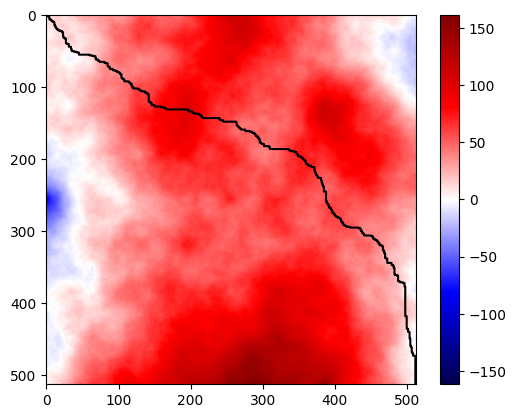

In [234]:
fig, ax = plt.subplots()
image = ax.imshow(img_centree, cmap="seismic", vmin=-162, vmax=162)
plt.colorbar(image, ax=ax)
ax.plot([i[0] for i in path], [i[1] for i in path], color="k")
plt.show()

In [235]:
compute_denivele(path)

np.float32(350.0)